In [2]:
from pathlib import Path
import zipfile
import pandas as pd

# Location of the 12 monthly BTS ZIP files
raw_folder = Path("Data/Raw")

results = []

for zip_path in sorted(raw_folder.glob("*.zip")):
    
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_files = [name for name in z.namelist() if name.lower().endswith(".csv")]
        
        if not csv_files:
            print(f"No CSV found in {zip_path.name}")
            continue
        
        csv_name = csv_files[0]
        
        # Read only one row — enough to identify year/month
        with z.open(csv_name) as f:
            sample = pd.read_csv(f, nrows=1)
        
        results.append({
            "File": zip_path.name,
            "Year": int(sample["YEAR"].iloc[0]),
            "Month": int(sample["MONTH"].iloc[0])
        })

month_check = pd.DataFrame(results).sort_values(["Year", "Month"])

month_check

,File,Year,Month
0,T_ONTIME_REPORTING_20260808_215307.zip,2025,1
1,T_ONTIME_REPORTING_20260808_215628.zip,2025,2
2,T_ONTIME_REPORTING_20260808_215839.zip,2025,3
3,T_ONTIME_REPORTING_20260808_215950.zip,2025,4
4,T_ONTIME_REPORTING_20260808_220117.zip,2025,5
5,T_ONTIME_REPORTING_20260808_220229.zip,2025,6
6,T_ONTIME_REPORTING_20260808_220338.zip,2025,7
7,T_ONTIME_REPORTING_20260808_220459.zip,2025,8
8,T_ONTIME_REPORTING_20260808_220634.zip,2025,9
9,T_ONTIME_REPORTING_20260808_220900.zip,2025,10


In [3]:
import zipfile
from pathlib import Path
import pandas as pd

raw_folder = Path("Data/Raw")

monthly_counts = []

for zip_path in sorted(raw_folder.glob("*.zip")):
    with zipfile.ZipFile(zip_path, "r") as z:
        csv_name = [name for name in z.namelist()
                    if name.lower().endswith(".csv")][0]

        with z.open(csv_name) as f:
            df_temp = pd.read_csv(
                f,
                usecols=["YEAR", "MONTH"]
            )

        monthly_counts.append({
            "Year": int(df_temp["YEAR"].iloc[0]),
            "Month": int(df_temp["MONTH"].iloc[0]),
            "Flights": len(df_temp)
        })

flight_counts = (
    pd.DataFrame(monthly_counts)
    .sort_values("Month")
    .reset_index(drop=True)
)

flight_counts.loc["Total"] = [
    2025,
    0,
    flight_counts["Flights"].sum()
]

flight_counts

,Year,Month,Flights
0,2025,1,539747
1,2025,2,504884
2,2025,3,600872
3,2025,4,583950
4,2025,5,605648
5,2025,6,611575
6,2025,7,631428
7,2025,8,602378
8,2025,9,562439
9,2025,10,605844


In [1]:
# ============================================================
# Build Combined 2025 Airline Analysis Dataset
# ============================================================

import pandas as pd
import zipfile
from pathlib import Path

raw_folder = Path("Data/Raw")

# Variables needed for descriptive analysis and modeling
columns_needed = [
    "YEAR",
    "QUARTER",
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "FL_DATE",
    "OP_UNIQUE_CARRIER",
    "OP_CARRIER_FL_NUM",
    "ORIGIN",
    "ORIGIN_CITY_NAME",
    "ORIGIN_STATE_ABR",
    "DEST",
    "DEST_CITY_NAME",
    "DEST_STATE_ABR",
    "CRS_DEP_TIME",
    "DEP_DELAY",
    "DEP_DELAY_NEW",
    "DEP_DEL15",
    "CRS_ARR_TIME",
    "ARR_DELAY",
    "ARR_DELAY_NEW",
    "ARR_DEL15",
    "CANCELLED",
    "CANCELLATION_CODE",
    "DIVERTED",
    "CRS_ELAPSED_TIME",
    "ACTUAL_ELAPSED_TIME",
    "AIR_TIME",
    "DISTANCE",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

monthly_data = []

for zip_path in sorted(raw_folder.glob("*.zip")):
    
    print(f"Loading {zip_path.name}...")
    
    with zipfile.ZipFile(zip_path, "r") as z:
        
        csv_name = [
            name for name in z.namelist()
            if name.lower().endswith(".csv")
        ][0]
        
        with z.open(csv_name) as f:
            df_month = pd.read_csv(
                f,
                usecols=columns_needed,
                low_memory=False
            )
            
        monthly_data.append(df_month)

airline = pd.concat(monthly_data, ignore_index=True)

print("\nCombined dataset created.")
print(f"Rows: {airline.shape[0]:,}")
print(f"Columns: {airline.shape[1]}")

airline.head()

Loading T_ONTIME_REPORTING_20260808_215307.zip...
Loading T_ONTIME_REPORTING_20260808_215628.zip...
Loading T_ONTIME_REPORTING_20260808_215839.zip...
Loading T_ONTIME_REPORTING_20260808_215950.zip...
Loading T_ONTIME_REPORTING_20260808_220117.zip...
Loading T_ONTIME_REPORTING_20260808_220229.zip...
Loading T_ONTIME_REPORTING_20260808_220338.zip...
Loading T_ONTIME_REPORTING_20260808_220459.zip...
Loading T_ONTIME_REPORTING_20260808_220634.zip...
Loading T_ONTIME_REPORTING_20260808_220900.zip...
Loading T_ONTIME_REPORTING_20260808_221107.zip...
Loading T_ONTIME_REPORTING_20260808_221312.zip...

Combined dataset created.
Rows: 7,001,619
Columns: 34


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1,JFK,"New York, NY",...,0.0,381.0,377.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,10,LAX,"Los Angeles, CA",...,0.0,330.0,290.0,274.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1002,MSN,"Madison, WI",...,0.0,141.0,125.0,91.0,708.0,20.0,0.0,0.0,0.0,0.0
3,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1004,PHL,"Philadelphia, PA",...,0.0,339.0,331.0,306.0,2176.0,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,1,3,1/1/2025 12:00:00 AM,AA,1005,ORD,"Chicago, IL",...,0.0,241.0,286.0,212.0,1440.0,0.0,0.0,44.0,0.0,0.0


In [2]:
# ============================================================
# Data Quality Audit
# ============================================================

print("DATASET OVERVIEW")
print("-" * 50)
print(f"Rows: {airline.shape[0]:,}")
print(f"Columns: {airline.shape[1]}")
print(f"Duplicate rows: {airline.duplicated().sum():,}")

# Cancellation and diversion counts
print("\nFLIGHT STATUS")
print("-" * 50)

cancelled = int(airline["CANCELLED"].sum())
diverted = int(airline["DIVERTED"].sum())

print(f"Cancelled flights: {cancelled:,} "
      f"({cancelled / len(airline) * 100:.2f}%)")

print(f"Diverted flights: {diverted:,} "
      f"({diverted / len(airline) * 100:.2f}%)")

# Target variable availability
print("\nTARGET VARIABLE: ARR_DEL15")
print("-" * 50)

print(airline["ARR_DEL15"].value_counts(dropna=False))

valid_target = airline["ARR_DEL15"].notna().sum()
missing_target = airline["ARR_DEL15"].isna().sum()

print(f"\nValid ARR_DEL15 values: {valid_target:,}")
print(f"Missing ARR_DEL15 values: {missing_target:,}")

# Missing values
missing = (
    airline.isna()
    .sum()
    .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] / len(airline) * 100
).round(2)

missing = missing.sort_values("Percent", ascending=False)

print("\nMISSING VALUES")
print("-" * 50)

display(missing)

DATASET OVERVIEW
--------------------------------------------------
Rows: 7,001,619
Columns: 34
Duplicate rows: 0

FLIGHT STATUS
--------------------------------------------------
Cancelled flights: 102,876 (1.47%)
Diverted flights: 19,258 (0.28%)

TARGET VARIABLE: ARR_DEL15
--------------------------------------------------
ARR_DEL15
0.0    5344846
1.0    1534638
NaN     122135
Name: count, dtype: int64

Valid ARR_DEL15 values: 6,879,484
Missing ARR_DEL15 values: 122,135

MISSING VALUES
--------------------------------------------------


,Missing,Percent
CANCELLATION_CODE,6898743,98.53
LATE_AIRCRAFT_DELAY,5466981,78.08
NAS_DELAY,5466981,78.08
WEATHER_DELAY,5466981,78.08
CARRIER_DELAY,5466981,78.08
SECURITY_DELAY,5466981,78.08
ACTUAL_ELAPSED_TIME,122135,1.74
AIR_TIME,122135,1.74
ARR_DELAY,122135,1.74
ARR_DEL15,122135,1.74


In [3]:
# ============================================================
# Create Completed-Flight Analysis Dataset
# ============================================================

analysis = airline[
    (airline["CANCELLED"] == 0) &
    (airline["DIVERTED"] == 0) &
    (airline["ARR_DEL15"].notna())
].copy()

# Convert target to integer
analysis["ARR_DEL15"] = analysis["ARR_DEL15"].astype(int)

print("COMPLETED-FLIGHT ANALYSIS DATASET")
print("-" * 50)

print(f"Original flights: {len(airline):,}")
print(f"Analysis flights: {len(analysis):,}")
print(f"Records excluded: {len(airline) - len(analysis):,}")

print("\nTARGET DISTRIBUTION")
print("-" * 50)

target_counts = analysis["ARR_DEL15"].value_counts().sort_index()
target_pct = analysis["ARR_DEL15"].value_counts(
    normalize=True
).sort_index() * 100

print(f"On time / <15 min late: {target_counts[0]:,} "
      f"({target_pct[0]:.2f}%)")

print(f"Delayed 15+ minutes:   {target_counts[1]:,} "
      f"({target_pct[1]:.2f}%)")

print("\nValidation:")
print("Cancelled flights remaining:", int(analysis["CANCELLED"].sum()))
print("Diverted flights remaining:", int(analysis["DIVERTED"].sum()))
print("Missing target values:", analysis["ARR_DEL15"].isna().sum())

COMPLETED-FLIGHT ANALYSIS DATASET
--------------------------------------------------
Original flights: 7,001,619
Analysis flights: 6,879,484
Records excluded: 122,135

TARGET DISTRIBUTION
--------------------------------------------------
On time / <15 min late: 5,344,846 (77.69%)
Delayed 15+ minutes:   1,534,638 (22.31%)

Validation:
Cancelled flights remaining: 0
Diverted flights remaining: 0
Missing target values: 0


,Month,Flights,Delayed_Flights,Delay_Rate_Pct
0,Jan,522269,98130,18.79
1,Feb,496476,103102,20.77
2,Mar,592301,116034,19.59
3,Apr,577730,113604,19.66
4,May,597574,141038,23.60
5,Jun,599472,169405,28.26
6,Jul,612811,177012,28.89
7,Aug,593733,133920,22.56
8,Sep,558328,92859,16.63
9,Oct,601570,122251,20.32


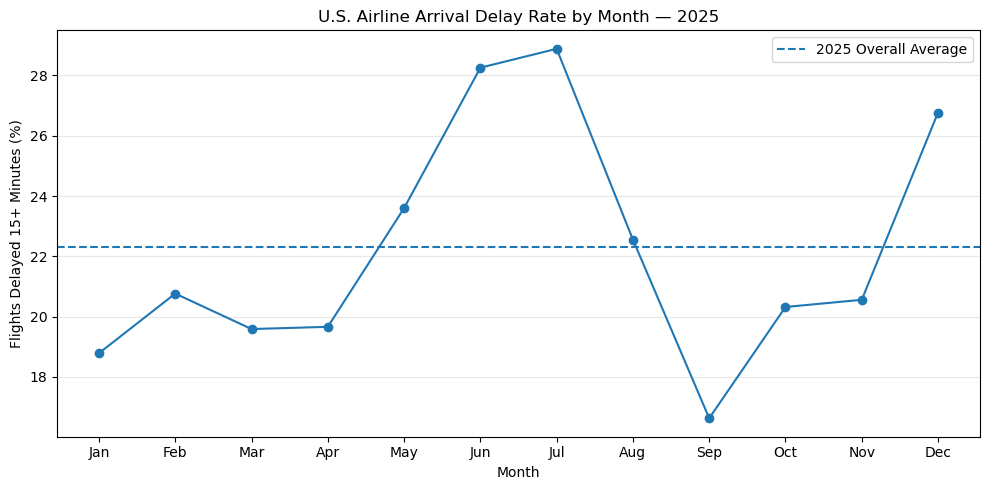

In [4]:
# ============================================================
# EDA 1: Arrival Delay Rate by Month
# ============================================================

import matplotlib.pyplot as plt

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_delay = (
    analysis.groupby("MONTH")
    .agg(
        Flights=("ARR_DEL15", "size"),
        Delayed_Flights=("ARR_DEL15", "sum"),
        Delay_Rate=("ARR_DEL15", "mean")
    )
    .reset_index()
)

monthly_delay["Delay_Rate_Pct"] = monthly_delay["Delay_Rate"] * 100
monthly_delay["Month"] = monthly_delay["MONTH"].map(month_names)

display(
    monthly_delay[
        ["Month", "Flights", "Delayed_Flights", "Delay_Rate_Pct"]
    ].round({"Delay_Rate_Pct": 2})
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_delay["Month"],
    monthly_delay["Delay_Rate_Pct"],
    marker="o"
)

plt.axhline(
    analysis["ARR_DEL15"].mean() * 100,
    linestyle="--",
    label="2025 Overall Average"
)

plt.title("U.S. Airline Arrival Delay Rate by Month — 2025")
plt.xlabel("Month")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

,OP_UNIQUE_CARRIER,Flights,Delayed_Flights,Delay_Rate_Pct
0,F9,194192,54202,27.91
1,OH,236682,65158,27.53
2,B6,226703,59288,26.15
3,AA,952841,244989,25.71
4,G4,129892,32428,24.97
5,AS,241927,55887,23.10
6,YX,334043,71857,21.51
7,UA,786377,168815,21.47
8,NK,191191,40931,21.41
9,WN,1376837,294575,21.40


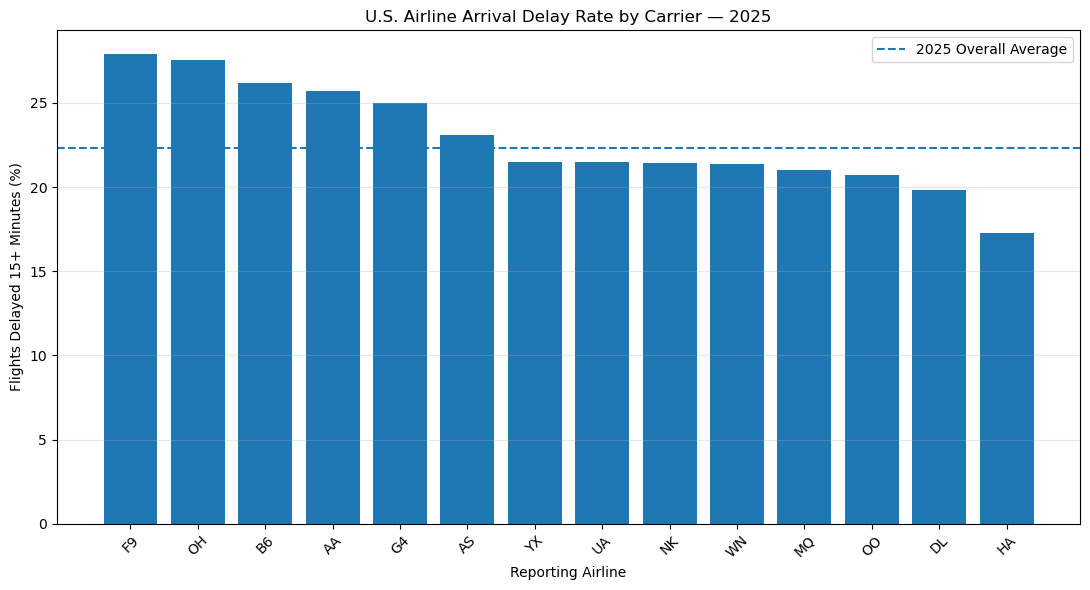

In [5]:
# ============================================================
# EDA 2: Arrival Delay Rate by Airline
# ============================================================

airline_delay = (
    analysis.groupby("OP_UNIQUE_CARRIER")
    .agg(
        Flights=("ARR_DEL15", "size"),
        Delayed_Flights=("ARR_DEL15", "sum"),
        Delay_Rate=("ARR_DEL15", "mean")
    )
    .reset_index()
)

airline_delay["Delay_Rate_Pct"] = airline_delay["Delay_Rate"] * 100

# Sort highest to lowest delay rate
airline_delay = airline_delay.sort_values(
    "Delay_Rate_Pct",
    ascending=False
).reset_index(drop=True)

display(
    airline_delay[
        [
            "OP_UNIQUE_CARRIER",
            "Flights",
            "Delayed_Flights",
            "Delay_Rate_Pct"
        ]
    ].round({"Delay_Rate_Pct": 2})
)

# Visualization
plt.figure(figsize=(11, 6))

plt.bar(
    airline_delay["OP_UNIQUE_CARRIER"],
    airline_delay["Delay_Rate_Pct"]
)

plt.axhline(
    analysis["ARR_DEL15"].mean() * 100,
    linestyle="--",
    label="2025 Overall Average"
)

plt.title("U.S. Airline Arrival Delay Rate by Carrier — 2025")
plt.xlabel("Reporting Airline")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Airports with at least 10,000 flights: 102

Top 15 Major Origin Airports by Arrival Delay Rate


,ORIGIN,Flights,Delayed_Flights,Delay_Rate_Pct
0,SFB,10420,3220,30.90
1,DFW,306185,87789,28.67
2,DCA,136684,37089,27.13
3,ORD,320418,84927,26.51
4,LGA,131177,34688,26.44
5,PHL,95211,25102,26.36
6,MIA,110113,28671,26.04
7,DEN,314281,80758,25.70
8,EWR,116940,29538,25.26
9,PBI,30181,7574,25.10


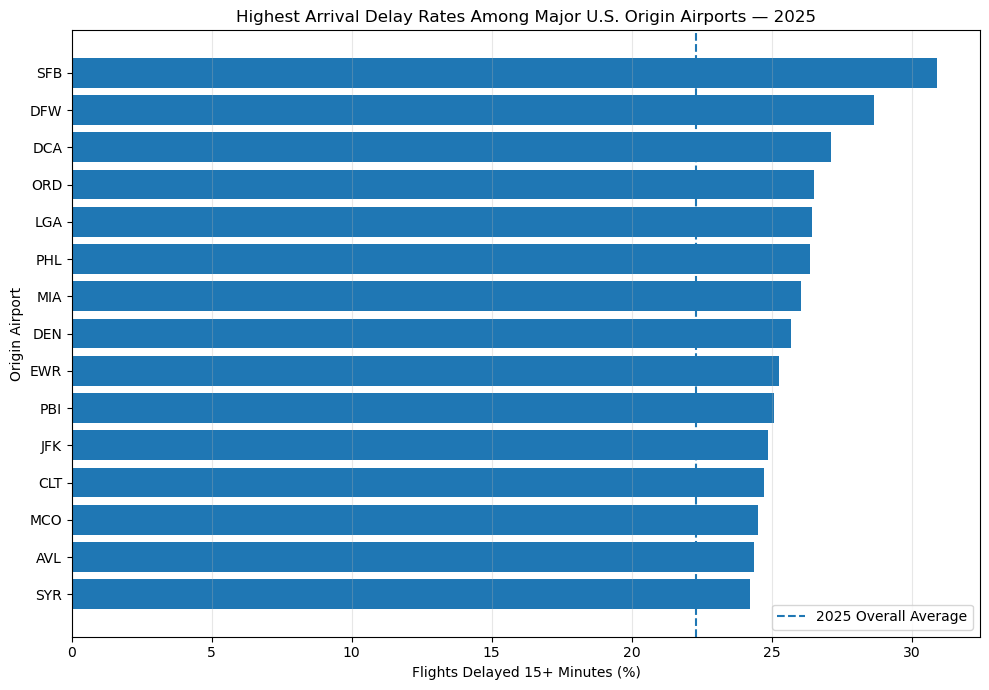

In [6]:
# ============================================================
# EDA 3: Arrival Delay Rate by Origin Airport
# Major airports with at least 10,000 completed flights
# ============================================================

airport_delay = (
    analysis.groupby("ORIGIN")
    .agg(
        Flights=("ARR_DEL15", "size"),
        Delayed_Flights=("ARR_DEL15", "sum"),
        Delay_Rate=("ARR_DEL15", "mean")
    )
    .reset_index()
)

airport_delay["Delay_Rate_Pct"] = airport_delay["Delay_Rate"] * 100

# Keep airports with substantial flight volume
major_airports = (
    airport_delay[airport_delay["Flights"] >= 10000]
    .sort_values("Delay_Rate_Pct", ascending=False)
    .reset_index(drop=True)
)

print(f"Airports with at least 10,000 flights: {len(major_airports)}")

print("\nTop 15 Major Origin Airports by Arrival Delay Rate")
display(
    major_airports[
        ["ORIGIN", "Flights", "Delayed_Flights", "Delay_Rate_Pct"]
    ]
    .head(15)
    .round({"Delay_Rate_Pct": 2})
)

# Top 15 for visualization
top_airports = major_airports.head(15).sort_values(
    "Delay_Rate_Pct",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_airports["ORIGIN"],
    top_airports["Delay_Rate_Pct"]
)

plt.axvline(
    analysis["ARR_DEL15"].mean() * 100,
    linestyle="--",
    label="2025 Overall Average"
)

plt.title("Highest Arrival Delay Rates Among Major U.S. Origin Airports — 2025")
plt.xlabel("Flights Delayed 15+ Minutes (%)")
plt.ylabel("Origin Airport")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Scheduled departure hour range:
0 to 24


,TIME_OF_DAY,Flights,Delayed_Flights,Delay_Rate_Pct
0,Early Morning,1170852,128805,11.00
1,Morning,1728956,288641,16.69
2,Afternoon,2006366,509201,25.38
3,Evening,1518651,483253,31.82
4,Late Night,454659,124738,27.44


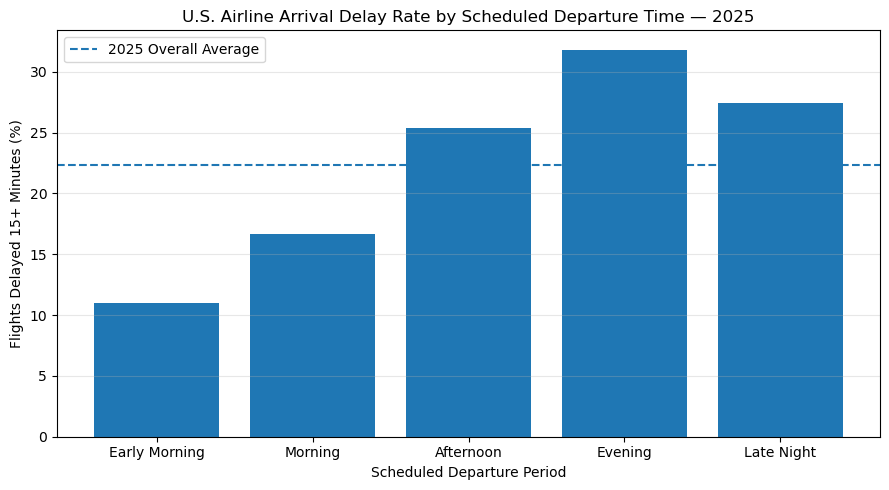

In [7]:
# ============================================================
# EDA 4: Arrival Delay Rate by Scheduled Departure Time
# ============================================================

# Convert HHMM scheduled departure time to hour
analysis["DEP_HOUR"] = (
    analysis["CRS_DEP_TIME"] // 100
).astype(int)

# Check the resulting hour values
print("Scheduled departure hour range:")
print(analysis["DEP_HOUR"].min(), "to", analysis["DEP_HOUR"].max())

# Create time-of-day categories
def time_period(hour):
    if 5 <= hour < 8:
        return "Early Morning"
    elif 8 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"

analysis["TIME_OF_DAY"] = analysis["DEP_HOUR"].apply(time_period)

# Set logical chronological order
time_order = [
    "Early Morning",
    "Morning",
    "Afternoon",
    "Evening",
    "Late Night"
]

time_delay = (
    analysis.groupby("TIME_OF_DAY", observed=True)
    .agg(
        Flights=("ARR_DEL15", "size"),
        Delayed_Flights=("ARR_DEL15", "sum"),
        Delay_Rate=("ARR_DEL15", "mean")
    )
    .reindex(time_order)
    .reset_index()
)

time_delay["Delay_Rate_Pct"] = time_delay["Delay_Rate"] * 100

display(
    time_delay[
        ["TIME_OF_DAY", "Flights", "Delayed_Flights", "Delay_Rate_Pct"]
    ].round({"Delay_Rate_Pct": 2})
)

# Visualization
plt.figure(figsize=(9, 5))

plt.bar(
    time_delay["TIME_OF_DAY"],
    time_delay["Delay_Rate_Pct"]
)

plt.axhline(
    analysis["ARR_DEL15"].mean() * 100,
    linestyle="--",
    label="2025 Overall Average"
)

plt.title("U.S. Airline Arrival Delay Rate by Scheduled Departure Time — 2025")
plt.xlabel("Scheduled Departure Period")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

,Day,Flights,Delayed_Flights,Delay_Rate_Pct
0,Monday,1031857,245421,23.78
1,Tuesday,931999,171382,18.39
2,Wednesday,951705,183569,19.29
3,Thursday,1021742,238281,23.32
4,Friday,1024839,238296,23.25
5,Saturday,890640,187061,21.00
6,Sunday,1026702,270628,26.36


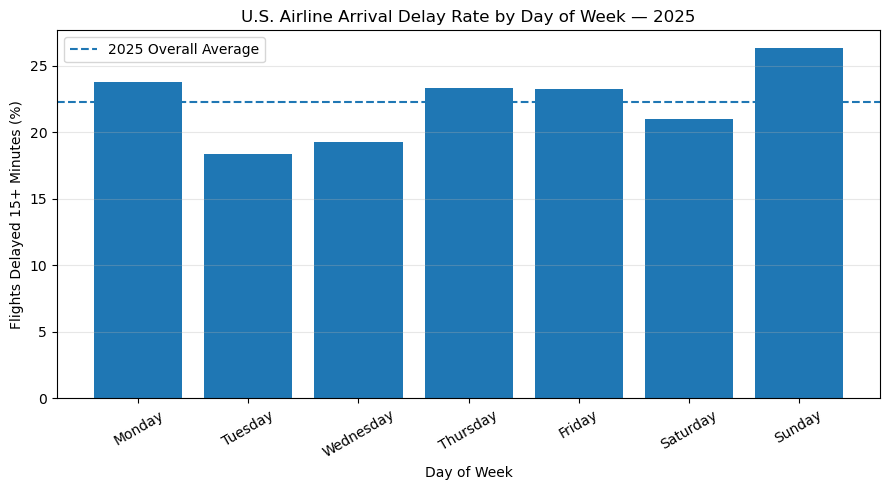

In [8]:
# ============================================================
# EDA 5: Arrival Delay Rate by Day of Week
# ============================================================

# BTS coding:
# 1 = Monday, 2 = Tuesday, ..., 7 = Sunday

day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

analysis["DAY_NAME"] = analysis["DAY_OF_WEEK"].map(day_names)

day_delay = (
    analysis.groupby("DAY_OF_WEEK")
    .agg(
        Flights=("ARR_DEL15", "size"),
        Delayed_Flights=("ARR_DEL15", "sum"),
        Delay_Rate=("ARR_DEL15", "mean")
    )
    .reset_index()
)

day_delay["Day"] = day_delay["DAY_OF_WEEK"].map(day_names)
day_delay["Delay_Rate_Pct"] = day_delay["Delay_Rate"] * 100

display(
    day_delay[
        ["Day", "Flights", "Delayed_Flights", "Delay_Rate_Pct"]
    ].round({"Delay_Rate_Pct": 2})
)

# Visualization
plt.figure(figsize=(9, 5))

plt.bar(
    day_delay["Day"],
    day_delay["Delay_Rate_Pct"]
)

plt.axhline(
    analysis["ARR_DEL15"].mean() * 100,
    linestyle="--",
    label="2025 Overall Average"
)

plt.title("U.S. Airline Arrival Delay Rate by Day of Week — 2025")
plt.xlabel("Day of Week")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

,DISTANCE_GROUP,Flights,Delayed_Flights,Avg_Distance,Delay_Rate_Pct
0,Under 500,2315511,493770,308.0,21.32
1,500–999,2499104,575181,737.0,23.02
2,"1,000–1,499",1135085,264955,1189.0,23.34
3,"1,500–1,999",489789,109679,1708.0,22.39
4,"2,000+",439995,91053,2448.0,20.69


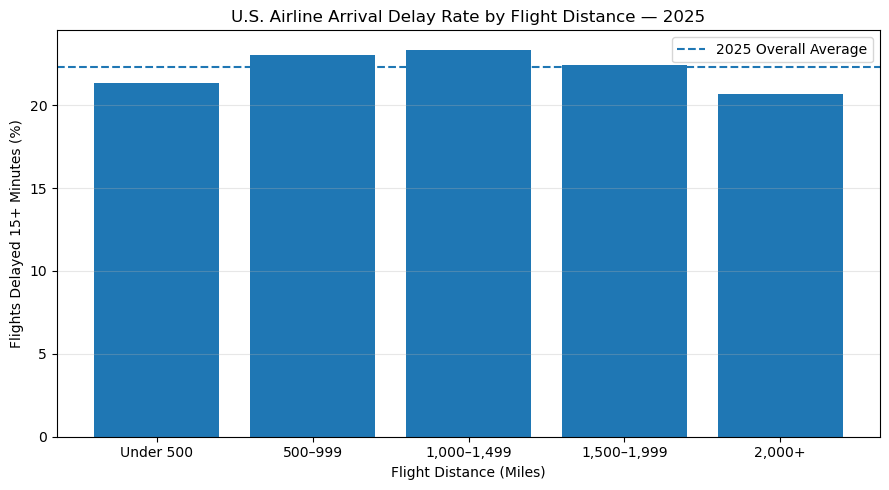

In [9]:
# ============================================================
# EDA 6: Arrival Delay Rate by Flight Distance
# ============================================================

# Create distance categories
distance_bins = [0, 500, 1000, 1500, 2000, float("inf")]

distance_labels = [
    "Under 500",
    "500–999",
    "1,000–1,499",
    "1,500–1,999",
    "2,000+"
]

analysis["DISTANCE_GROUP"] = pd.cut(
    analysis["DISTANCE"],
    bins=distance_bins,
    labels=distance_labels,
    right=False
)

distance_delay = (
    analysis.groupby("DISTANCE_GROUP", observed=True)
    .agg(
        Flights=("ARR_DEL15", "size"),
        Delayed_Flights=("ARR_DEL15", "sum"),
        Delay_Rate=("ARR_DEL15", "mean"),
        Avg_Distance=("DISTANCE", "mean")
    )
    .reset_index()
)

distance_delay["Delay_Rate_Pct"] = (
    distance_delay["Delay_Rate"] * 100
)

display(
    distance_delay[
        [
            "DISTANCE_GROUP",
            "Flights",
            "Delayed_Flights",
            "Avg_Distance",
            "Delay_Rate_Pct"
        ]
    ].round({
        "Avg_Distance": 0,
        "Delay_Rate_Pct": 2
    })
)

# Visualization
plt.figure(figsize=(9, 5))

plt.bar(
    distance_delay["DISTANCE_GROUP"].astype(str),
    distance_delay["Delay_Rate_Pct"]
)

plt.axhline(
    analysis["ARR_DEL15"].mean() * 100,
    linestyle="--",
    label="2025 Overall Average"
)

plt.title(
    "U.S. Airline Arrival Delay Rate by Flight Distance — 2025"
)
plt.xlabel("Flight Distance (Miles)")
plt.ylabel("Flights Delayed 15+ Minutes (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# MODELING 1: Create Pre-Flight Modeling Dataset
# ============================================================

model_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE"
]

target = "ARR_DEL15"

model_data = analysis[model_features + [target]].copy()

print("MODELING DATASET")
print("-" * 50)
print(f"Rows before missing-value removal: {len(model_data):,}")

# Check missing values
missing_model = (
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values:")
print(missing_model)

# Remove records missing required modeling information
model_data = model_data.dropna().copy()

print("\nAfter removing missing values:")
print(f"Rows: {len(model_data):,}")
print(f"Columns: {model_data.shape[1]}")

print("\nTarget distribution:")
target_counts = model_data[target].value_counts().sort_index()
target_pct = model_data[target].value_counts(
    normalize=True
).sort_index() * 100

for value in target_counts.index:
    label = "On Time / <15 min late" if value == 0 else "Delayed 15+ minutes"
    print(
        f"{label}: "
        f"{target_counts[value]:,} "
        f"({target_pct[value]:.2f}%)"
    )

display(model_data.head())

MODELING DATASET
--------------------------------------------------
Rows before missing-value removal: 6,879,484

Missing values:
MONTH                0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
ORIGIN               0
DEST                 0
CRS_DEP_TIME         0
CRS_ARR_TIME         0
CRS_ELAPSED_TIME     0
DISTANCE             0
ARR_DEL15            0
dtype: int64

After removing missing values:
Rows: 6,879,484
Columns: 10

Target distribution:
On Time / <15 min late: 5,344,846 (77.69%)
Delayed 15+ minutes: 1,534,638 (22.31%)


,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,ARR_DEL15
0,1,3,AA,JFK,LAX,659,1020,381.0,2475.0,0
1,1,3,AA,LAX,JFK,2200,630,330.0,2475.0,0
2,1,3,AA,MSN,CLT,644,1005,141.0,708.0,1
3,1,3,AA,PHL,LAS,1855,2134,339.0,2176.0,0
4,1,3,AA,ORD,PHX,830,1131,241.0,1440.0,1


In [11]:
# ============================================================
# MODELING 2: Stratified Sample and Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Separate predictors and target
X = model_data.drop(columns="ARR_DEL15")
y = model_data["ARR_DEL15"].astype(int)

# ------------------------------------------------------------
# Create a 1,000,000-row stratified development sample
# ------------------------------------------------------------

X_dev, _, y_dev, _ = train_test_split(
    X,
    y,
    train_size=1_000_000,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 80/20 train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    stratify=y_dev,
    random_state=42
)

print("MODEL DEVELOPMENT SAMPLE")
print("-" * 50)

print(f"Development sample: {len(X_dev):,}")
print(f"Training set:       {len(X_train):,}")
print(f"Test set:           {len(X_test):,}")

print("\nTARGET DISTRIBUTION")

for name, target_set in [
    ("Development", y_dev),
    ("Training", y_train),
    ("Test", y_test)
]:
    delayed_pct = target_set.mean() * 100

    print(
        f"{name:<12}: "
        f"{len(target_set):>9,} flights | "
        f"{delayed_pct:.2f}% delayed"
    )

# ------------------------------------------------------------
# Baseline classifier
# Always predicts the majority class (not delayed)
# ------------------------------------------------------------

baseline_accuracy = (y_test == 0).mean()

print("\nBASELINE MODEL")
print("-" * 50)
print("Prediction: Every flight = Not Delayed")
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

MODEL DEVELOPMENT SAMPLE
--------------------------------------------------
Development sample: 1,000,000
Training set:       800,000
Test set:           200,000

TARGET DISTRIBUTION
Development : 1,000,000 flights | 22.31% delayed
Training    :   800,000 flights | 22.31% delayed
Test        :   200,000 flights | 22.31% delayed

BASELINE MODEL
--------------------------------------------------
Prediction: Every flight = Not Delayed
Baseline Accuracy: 0.7769
Baseline Accuracy: 77.69%


In [12]:
# ============================================================
# MODELING 3: Logistic Regression
# ============================================================

import time
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Define feature types
# ------------------------------------------------------------

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST"
]

numeric_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE"
]

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

# ------------------------------------------------------------
# Logistic Regression pipeline
# ------------------------------------------------------------

log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

print("Training Logistic Regression...")

start_time = time.time()

log_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.1f} seconds.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

log_preds = log_model.predict(X_test)

log_probs = log_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)
log_auc = roc_auc_score(y_test, log_probs)

print("\nLOGISTIC REGRESSION RESULTS")
print("-" * 50)

print(f"Accuracy:  {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall:    {log_recall:.4f}")
print(f"F1 Score:  {log_f1:.4f}")
print(f"ROC-AUC:   {log_auc:.4f}")

print("\nBaseline Accuracy:")
print(f"{baseline_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        log_preds,
        target_names=[
            "Not Delayed",
            "Delayed 15+"
        ]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_preds))

Training Logistic Regression...
Training completed in 8.5 seconds.

LOGISTIC REGRESSION RESULTS
--------------------------------------------------
Accuracy:  0.6056
Precision: 0.3099
Recall:    0.6258
F1 Score:  0.4145
ROC-AUC:   0.6512

Baseline Accuracy:
0.7769

Classification Report:
              precision    recall  f1-score   support

 Not Delayed       0.85      0.60      0.70    155385
 Delayed 15+       0.31      0.63      0.41     44615

    accuracy                           0.61    200000
   macro avg       0.58      0.61      0.56    200000
weighted avg       0.73      0.61      0.64    200000


Confusion Matrix:
[[93198 62187]
 [16693 27922]]


In [13]:
# ============================================================
# MODELING 4: Random Forest
# ============================================================

import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Random Forest preprocessing
#
# Use the same feature representation as Logistic Regression,
# but numeric variables do not require scaling for trees.
# ------------------------------------------------------------

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

# ------------------------------------------------------------
# Random Forest pipeline
# ------------------------------------------------------------

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=18,
                min_samples_leaf=10,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

print("Training Random Forest...")

start_time = time.time()

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.1f} seconds.")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print("\nRANDOM FOREST RESULTS")
print("-" * 50)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_preds,
        target_names=[
            "Not Delayed",
            "Delayed 15+"
        ]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

Training Random Forest...
Training completed in 44.5 seconds.

RANDOM FOREST RESULTS
--------------------------------------------------
Accuracy:  0.6022
Precision: 0.3109
Recall:    0.6437
F1 Score:  0.4193
ROC-AUC:   0.6681

Classification Report:
              precision    recall  f1-score   support

 Not Delayed       0.85      0.59      0.70    155385
 Delayed 15+       0.31      0.64      0.42     44615

    accuracy                           0.60    200000
   macro avg       0.58      0.62      0.56    200000
weighted avg       0.73      0.60      0.64    200000


Confusion Matrix:
[[91724 63661]
 [15895 28720]]


In [14]:
# ============================================================
# MODELING 5: Model Comparison
# ============================================================

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy
    ],
    "Precision": [
        0.0,
        log_precision,
        rf_precision
    ],
    "Recall": [
        0.0,
        log_recall,
        rf_recall
    ],
    "F1 Score": [
        0.0,
        log_f1,
        rf_f1
    ],
    "ROC-AUC": [
        0.500,
        log_auc,
        rf_auc
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.777,0.000,0.000,0.000,0.500
1,Logistic Regression,0.606,0.310,0.626,0.415,0.651
2,Random Forest,0.602,0.311,0.644,0.419,0.668


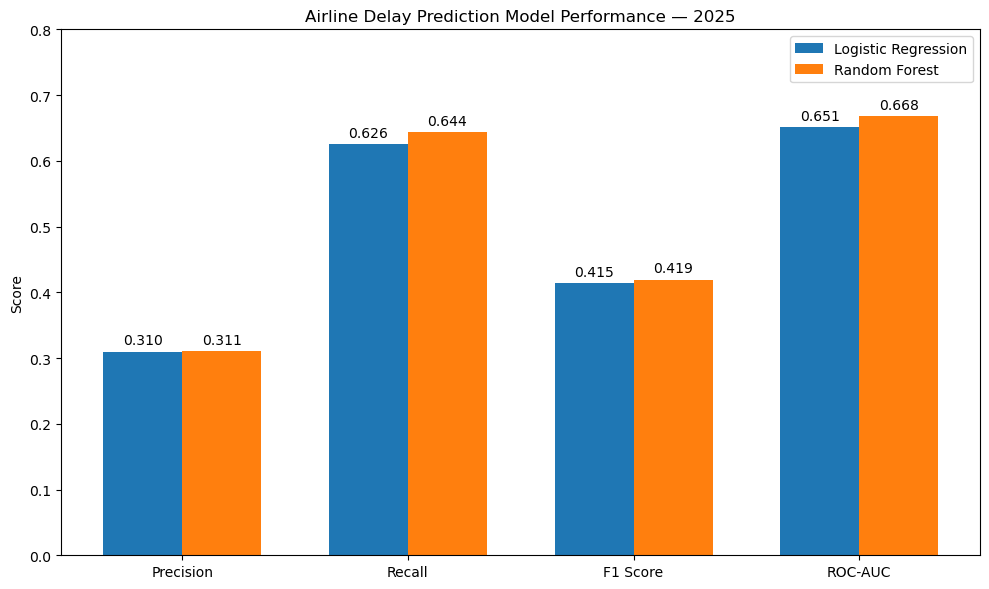

In [15]:
# ============================================================
# MODELING 6: Model Performance Visualization
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Compare predictive models only
plot_data = model_comparison[
    model_comparison["Model"].isin(["Logistic Regression", "Random Forest"])
].copy()

metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

log_values = plot_data.iloc[0][metrics].astype(float).values
rf_values = plot_data.iloc[1][metrics].astype(float).values

bars1 = ax.bar(
    x - width/2,
    log_values,
    width,
    label="Logistic Regression"
)

bars2 = ax.bar(
    x + width/2,
    rf_values,
    width,
    label="Random Forest"
)

ax.set_title("Airline Delay Prediction Model Performance — 2025")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 0.8)
ax.legend()

ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# MODELING 7: Random Forest Feature Importance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names from the preprocessing pipeline
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importance values
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top 20 individual transformed features
print("TOP 20 RANDOM FOREST FEATURES")
print("-" * 55)
display(feature_importance.head(20))

TOP 20 RANDOM FOREST FEATURES
-------------------------------------------------------


,Feature,Importance
720,num__CRS_ARR_TIME,0.323309
719,num__CRS_DEP_TIME,0.319589
717,num__MONTH,0.070901
718,num__DAY_OF_WEEK,0.034149
721,num__CRS_ELAPSED_TIME,0.025026
722,num__DISTANCE,0.014694
104,cat__ORIGIN_DFW,0.013536
0,cat__OP_UNIQUE_CARRIER_AA,0.013467
3,cat__OP_UNIQUE_CARRIER_DL,0.008358
12,cat__OP_UNIQUE_CARRIER_WN,0.008033


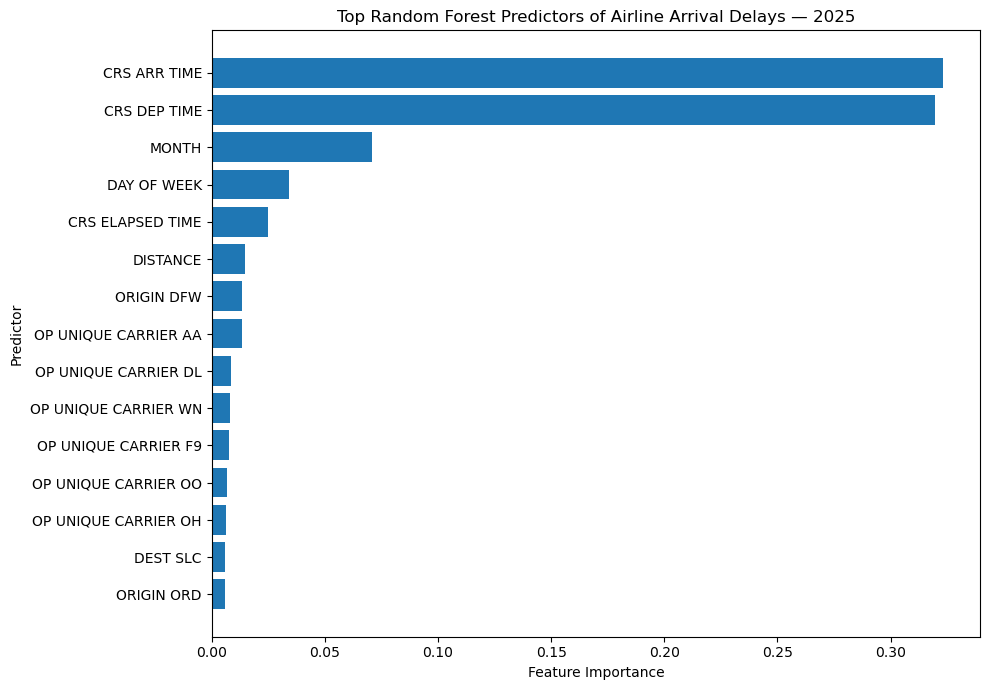

In [17]:
# ============================================================
# MODELING 8: Top Random Forest Feature Importances
# ============================================================

# Select the 15 most important features
top_features = feature_importance.head(15).copy()

# Clean feature names for presentation
top_features["Feature_Label"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ")
)

# Reverse order so highest importance appears at top
plot_features = top_features.sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_features["Feature_Label"],
    plot_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Top Random Forest Predictors of Airline Arrival Delays — 2025")

plt.tight_layout()
plt.show()